# Week 5 - Feature Engineering and Dimensionality Reduction

This notebook builds feature matrices, runs PCA/SVD, computes reconstruction error, produces visualizations, and persists artifacts for the Week 5 deliverable.

**Reproducible pipeline:** The same logic is exposed as a script in `src/feature_engineering.py`. From the project root run:

```bash
python src/feature_engineering.py
```

This regenerates the feature matrices, fitted models and metrics under `artifacts/`.

In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "src" else os.getcwd()
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
RANDOM_STATE = 42

## Load data
We start from the catalog file and the processed parquet (full or stratified sample).

In [ ]:
catalog_path = os.path.join(PROJECT_ROOT, "data", "raw", "catalog", "games_may2024_full.csv")
parquet_full = os.path.join(PROJECT_ROOT, "data", "processed", "steam_full.parquet")
parquet_v1 = os.path.join(PROJECT_ROOT, "data", "processed", "steam_v1.parquet")
parquet_path = parquet_full if os.path.exists(parquet_full) else parquet_v1

catalog_df = pd.read_csv(catalog_path)
reviews_df = pd.read_parquet(parquet_path)
catalog_df["AppID"] = catalog_df["AppID"].astype(str)
reviews_df["AppID"] = reviews_df["AppID"].astype(str)
reviews_df = reviews_df[["AppID", "voted_up", "author_playtime_forever"]].copy()
reviews_df["voted_up"] = reviews_df["voted_up"].astype(float)
agg = reviews_df.groupby("AppID", as_index=False).agg(
    reviews_count=("voted_up", "size"),
    voted_up_rate=("voted_up", "mean"),
    playtime_mean=("author_playtime_forever", "mean"),
    playtime_median=("author_playtime_forever", "median"),
)
df = catalog_df.merge(agg, on="AppID", how="left")
review_coverage = df["reviews_count"].notna().mean()
print(f"Catalog rows: {len(df):,} | Reviews source: {os.path.basename(parquet_path)}")
print(f"Review-aggregate coverage: {review_coverage:.1%} of catalog rows")
df.head(3)

## Feature construction
Numeric, categorical (multi-label), text, and temporal features.

In [ ]:
import re
from collections import Counter

def normalize_multilabel(value):
    if pd.isna(value):
        return []
    text = str(value)
    text = text.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    parts = re.split(r"[;,]", text)
    return [p.strip() for p in parts if p.strip()]

# Numeric features. Review-aggregate columns (reviews_count, voted_up_rate,
# playtime_mean, playtime_median) are intentionally excluded: the V1 parquet
# only covers ~500 games (stratified sample), so these columns are NaN for
# >99% of the catalog and would inject pure noise into PCA. Steam's own
# `positive`, `negative`, `pct_pos_total`, `num_reviews_total` already cover
# the same signal across the full catalog.
numeric_cols = [
    "required_age", "price", "dlc_count", "metacritic_score",
    "achievements", "recommendations", "user_score", "score_rank",
    "positive", "negative", "estimated_owners", "average_playtime_forever",
    "average_playtime_2weeks", "median_playtime_forever", "median_playtime_2weeks",
    "peak_ccu", "pct_pos_total", "num_reviews_total", "pct_pos_recent",
    "num_reviews_recent",
]
for col in ["windows", "mac", "linux"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)
    numeric_cols.append(col)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce", utc=True).dt.tz_localize(None)
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
current_date = pd.Timestamp.utcnow().tz_localize(None).normalize()
df["release_age_days"] = (current_date - df["release_date"]).dt.days
numeric_cols += ["release_year", "release_month", "release_age_days"]

numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(numeric_df.median(numeric_only=True)).fillna(0)
# Clip outliers at 1/99 percentiles before scaling (a few AAA outliers
# otherwise dominate every principal direction).
lower = numeric_df.quantile(0.01)
upper = numeric_df.quantile(0.99)
numeric_df = numeric_df.clip(lower, upper, axis=1)

scaler = StandardScaler()
X_numeric = scaler.fit_transform(numeric_df.values)

cat_cols = ["genres", "categories", "tags", "developers", "publishers", "supported_languages", "full_audio_languages"]
cat_rows = []
counts = Counter()
for _, row in df[cat_cols].iterrows():
    tokens = []
    for col in cat_cols:
        for val in normalize_multilabel(row[col]):
            tokens.append(f"{col}__{val.lower()}")
    cat_rows.append(tokens)
    counts.update(tokens)
min_freq = 20
max_features_cat = 5000
allowed = [t for t, c in counts.items() if c >= min_freq]
if len(allowed) > max_features_cat:
    allowed = [t for t, _ in counts.most_common(max_features_cat)]
allowed_set = set(allowed)
cat_rows = [[t for t in row if t in allowed_set] for row in cat_rows]
mlb = MultiLabelBinarizer(classes=sorted(allowed_set), sparse_output=True)
X_cat = mlb.fit_transform(cat_rows).tocsr()

text_cols = ["name", "short_description", "about_the_game", "detailed_description"]
text_df = df[text_cols].fillna("")
text_blob = (
    text_df["name"] + " " + text_df["short_description"] + " "
    + text_df["about_the_game"] + " " + text_df["detailed_description"]
)
tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.95, ngram_range=(1, 2))
X_text = tfidf.fit_transform(text_blob.values)

print(f"X_numeric:     {X_numeric.shape}")
print(f"X_categorical: {X_cat.shape}  (sparse, {X_cat.nnz:,} nnz)")
print(f"X_text:        {X_text.shape}  (sparse, {X_text.nnz:,} nnz)")

## Feature engineering rationale
- **Numeric features:** capture scale-sensitive signals (price, playtime, popularity, ratings). We standardize them so PCA is not dominated by large units.
- **Temporal features:** release year/month/age encode lifecycle effects and recency, which often explain variance in engagement.
- **Categorical multi-label features:** genres, tags, developers, publishers, and languages define the game identity. We use multi-label binarization and filter rare tokens to control dimensionality.
- **Text features (TF-IDF):** descriptions and titles capture semantic content; TF-IDF emphasizes informative terms while downweighting common words.
- **Outlier handling:** clipping extreme values reduces distortion in PCA scatter and stabilizes variance estimates.
- **Why PCA on numeric:** it summarizes correlated numeric signals into fewer components while retaining most variance.
- **Why SVD on text:** TF-IDF matrices are sparse and high-dimensional; SVD provides compact semantic factors.

## PCA on numeric features
We report individual and cumulative explained variance.

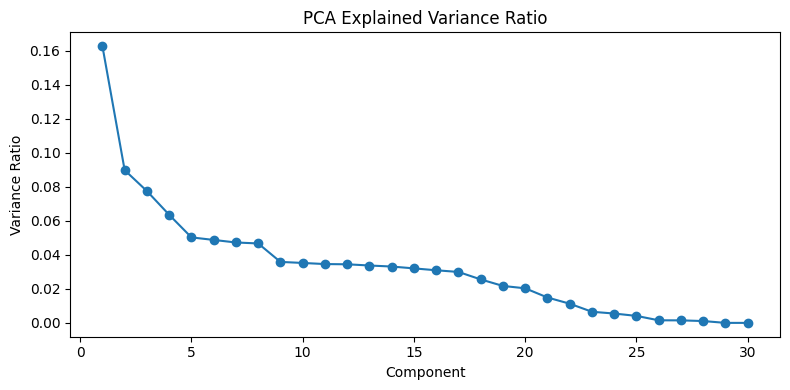

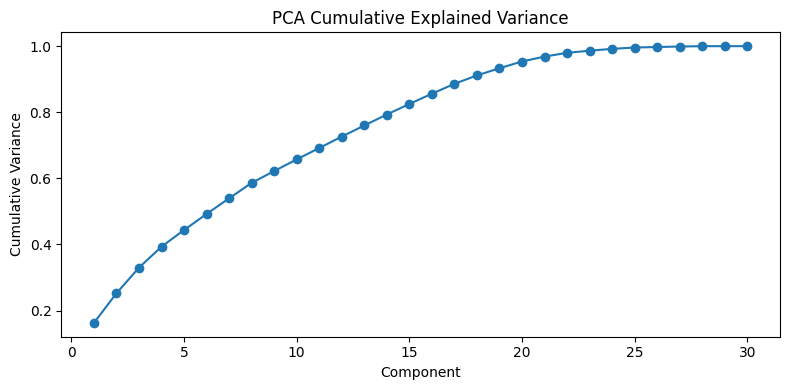

{'explained_variance_ratio': [0.16261194928569425,
  0.08974986261821466,
  0.07746029306140191,
  0.06351637177306044,
  0.050240160463453906,
  0.04875248551602904,
  0.047250225167929816,
  0.04668010937605406,
  0.035833519617857176,
  0.03522301495870773,
  0.03456560116274156,
  0.03443202808764163,
  0.03372091159142658,
  0.03311068094467062,
  0.032029045702716856,
  0.03092074819732063,
  0.029931586733953686,
  0.025549645875615076,
  0.0217063365422476,
  0.02032172816487983,
  0.014911289451809324,
  0.011273471898032284,
  0.006530964537058555,
  0.00549309930742368,
  0.004104244318457568,
  0.001517430025490238,
  0.0014819905631800092,
  0.001080086623207661,
  1.1184337236452904e-06,
  0.0],
 'cumulative_explained_variance': [0.16261194928569425,
  0.25236181190390894,
  0.32982210496531084,
  0.3933384767383713,
  0.4435786372018252,
  0.4923311227178543,
  0.539581347885784,
  0.5862614572618381,
  0.6220949768796953,
  0.657317991838403,
  0.6918835930011445,
  0.7

In [9]:
pca = PCA(n_components=min(100, X_numeric.shape[1]))
pca_fit = pca.fit(X_numeric)
pca_var = pca_fit.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca_var) + 1), pca_var, marker="o")
plt.title("PCA Explained Variance Ratio")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca_var) + 1), np.cumsum(pca_var), marker="o")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Component")
plt.ylabel("Cumulative Variance")
plt.tight_layout()
plt.show()

pca_output = {
    "explained_variance_ratio": pca_var.tolist(),
    "cumulative_explained_variance": np.cumsum(pca_var).tolist(),
}
pca_output

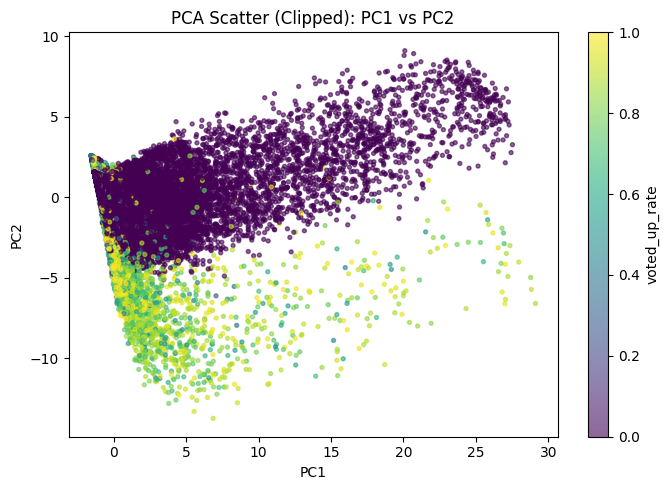

In [13]:
# Clip outliers (1% - 99%) para estabilizar el PCA
numeric_clip = numeric_df.copy()
lower = numeric_clip.quantile(0.01)
upper = numeric_clip.quantile(0.99)
numeric_clip = numeric_clip.clip(lower, upper, axis=1)

scaler = StandardScaler()
X_numeric_clip = scaler.fit_transform(numeric_clip.values)

# PCA scatter con datos recortados
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_numeric_clip)

color = df["voted_up_rate"].fillna(0).values
plt.figure(figsize=(7, 5))
sc = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=color, cmap="viridis", s=8, alpha=0.6)
plt.title("PCA Scatter (Clipped): PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="voted_up_rate")
plt.tight_layout()
plt.show()

## SVD on text features
We report individual and cumulative explained variance for TF-IDF features.

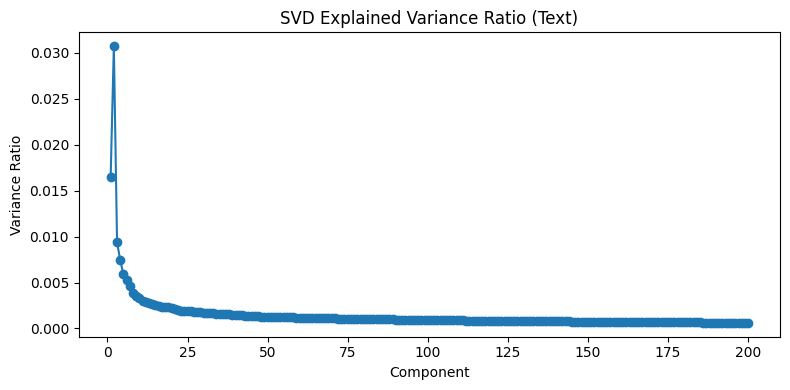

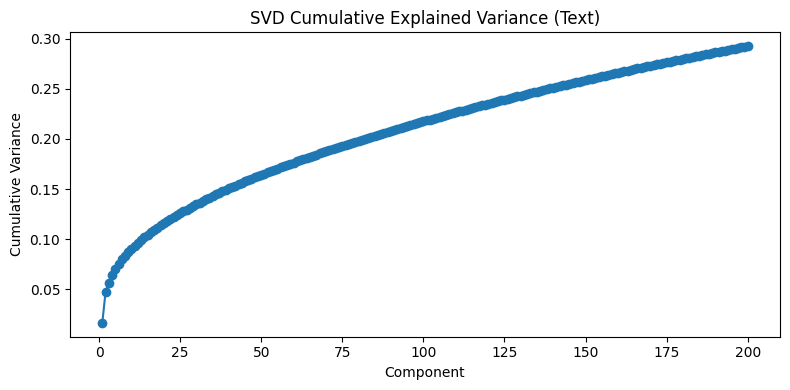

In [10]:
svd = TruncatedSVD(n_components=min(200, X_text.shape[1] - 1))
svd_fit = svd.fit(X_text)
svd_var = svd_fit.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(svd_var) + 1), svd_var, marker="o")
plt.title("SVD Explained Variance Ratio (Text)")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(svd_var) + 1), np.cumsum(svd_var), marker="o")
plt.title("SVD Cumulative Explained Variance (Text)")
plt.xlabel("Component")
plt.ylabel("Cumulative Variance")
plt.tight_layout()
plt.show()